# TASK 2

### EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv("train (1).csv")
test = pd.read_csv("test (1).csv")
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

Train Shape: (59598, 24)
Test Shape : (14900, 24)


In [4]:
train.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [6]:
train.isnull().sum().sort_values(ascending=False)

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

In [7]:
train["Attrition"].value_counts()

Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64

In [8]:
train.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,21519.150028,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


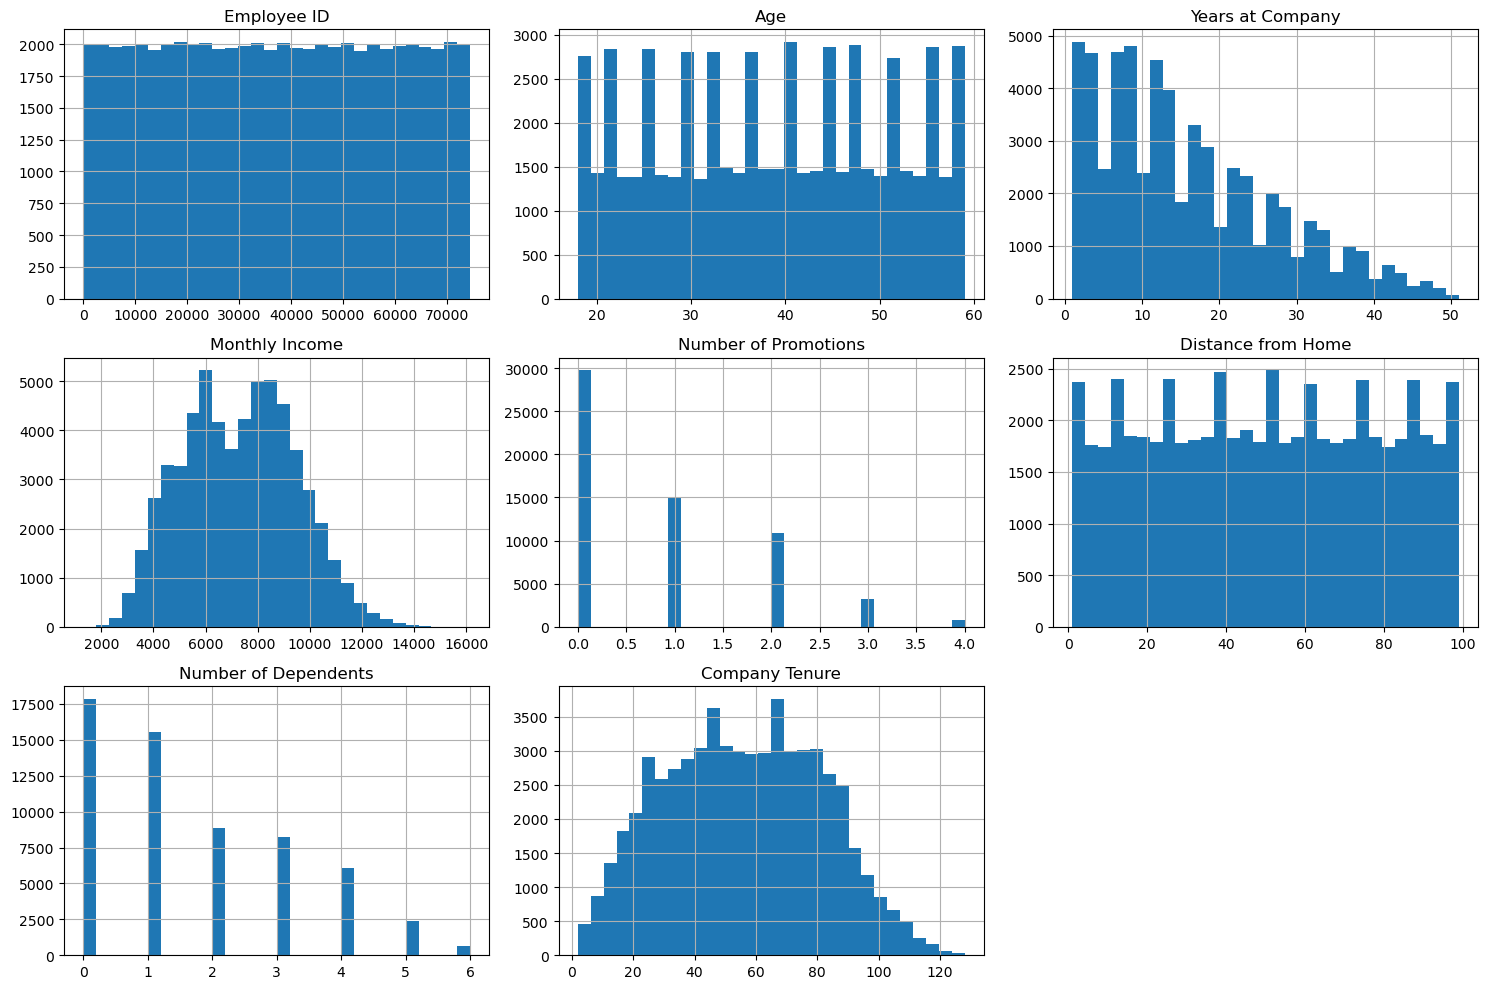

In [9]:
train.hist(
    figsize=(15,10),
    bins=30
)
plt.tight_layout()
plt.show()

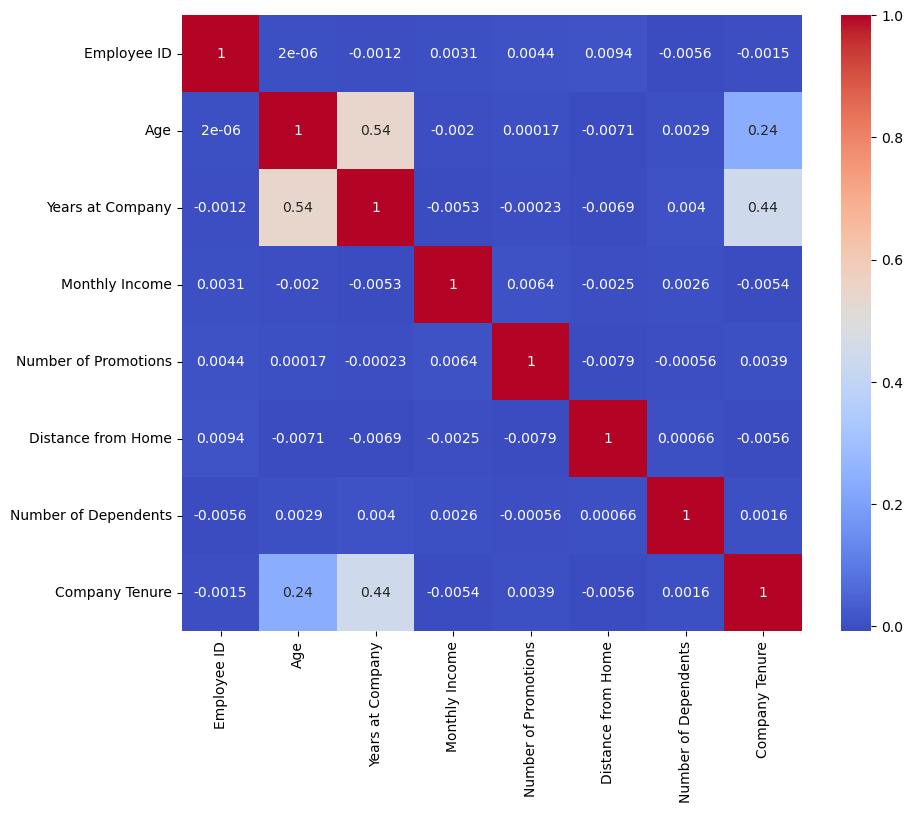

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(
    train.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

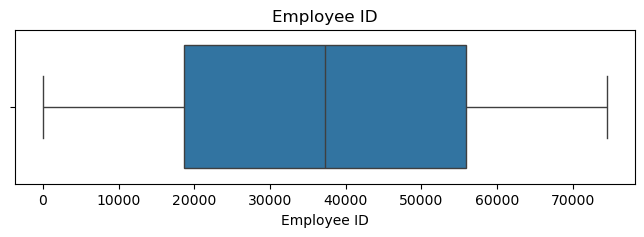

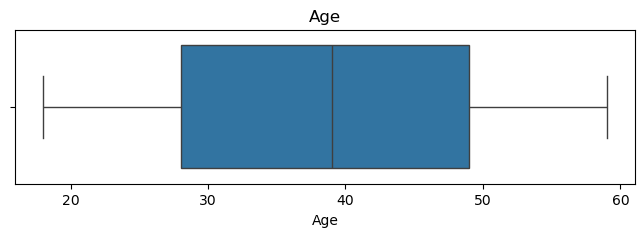

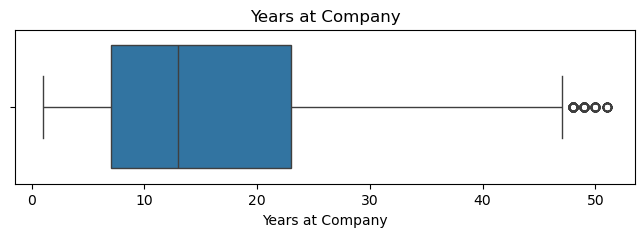

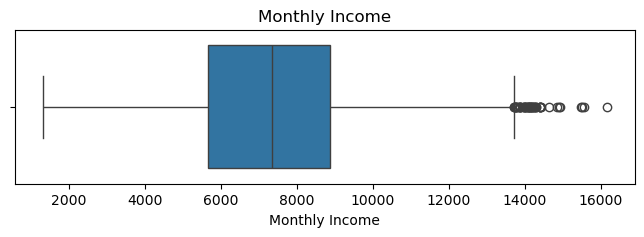

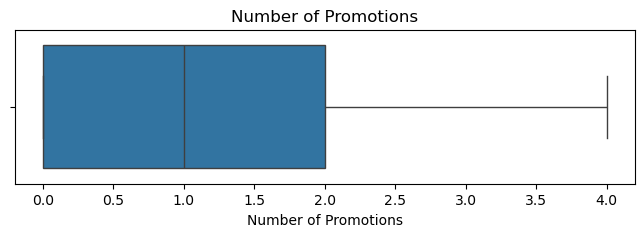

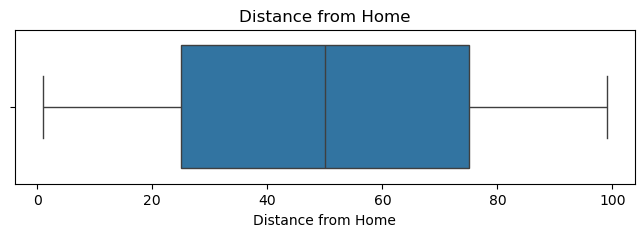

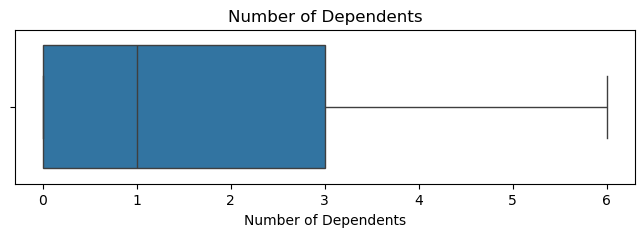

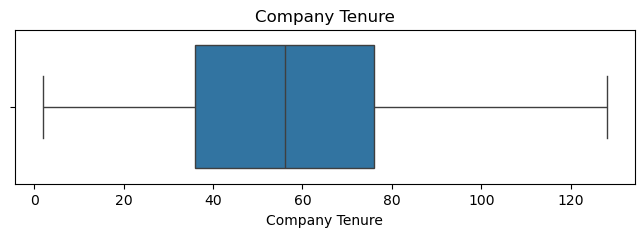

In [11]:
num_cols = train.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

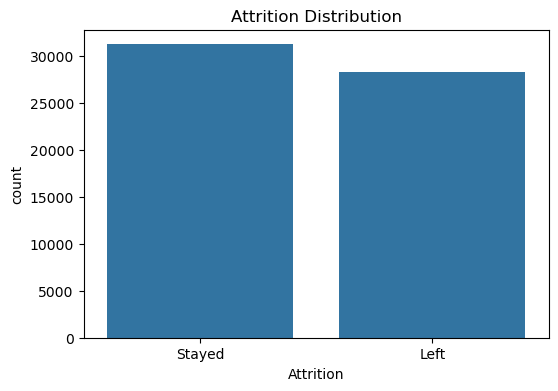

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=train,
    x="Attrition"
)
plt.title("Attrition Distribution")
plt.show()

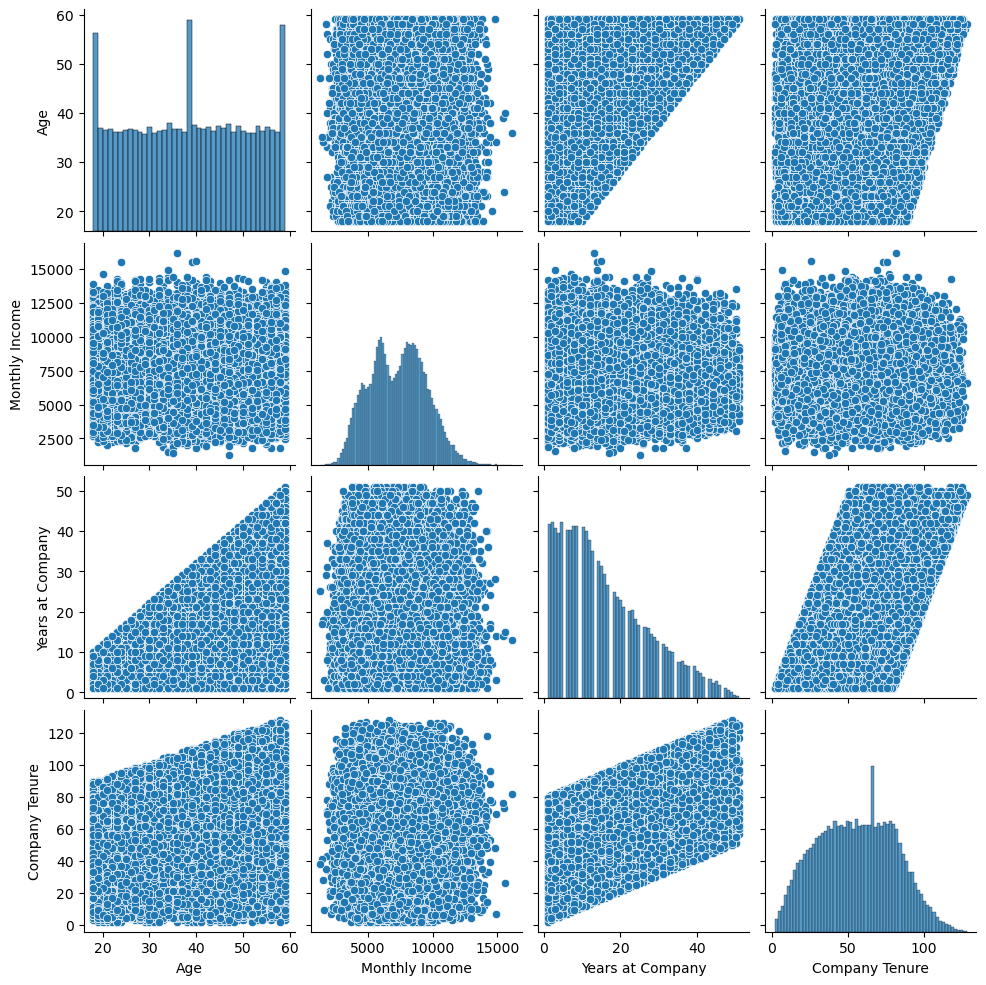

In [13]:
selected_cols = [
    "Age",
    "Monthly Income",
    "Years at Company",
    "Company Tenure"
]
sns.pairplot(train[selected_cols])
plt.show()

In [14]:
train.drop("Employee ID", axis=1, inplace=True)
test.drop("Employee ID", axis=1, inplace=True)

In [15]:
train["Attrition"] = train["Attrition"].map({
    "Stayed":0,
    "Left":1
})

In [16]:
X = train.drop("Attrition", axis=1)
y = train["Attrition"]
print(X.shape)
print(y.shape)

(59598, 22)
(59598,)


In [17]:
X = pd.get_dummies(
    X,
    drop_first=True
)
test_encoded = pd.get_dummies(
    test,
    drop_first=True
)

In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                59598 non-null  int64
 1   Years at Company                   59598 non-null  int64
 2   Monthly Income                     59598 non-null  int64
 3   Number of Promotions               59598 non-null  int64
 4   Distance from Home                 59598 non-null  int64
 5   Number of Dependents               59598 non-null  int64
 6   Company Tenure                     59598 non-null  int64
 7   Gender_Male                        59598 non-null  bool 
 8   Job Role_Finance                   59598 non-null  bool 
 9   Job Role_Healthcare                59598 non-null  bool 
 10  Job Role_Media                     59598 non-null  bool 
 11  Job Role_Technology                59598 non-null  bool 
 12  Work-Life Balance_

In [19]:
test_encoded = test_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_valid.shape)

(47678, 41)
(11920, 41)


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(test_encoded)

### Model Implementation And Model Evaluation & Comparison

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [23]:
results = {}

In [71]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_valid_scaled)
results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_valid, lr_pred),
    "Precision": precision_score(y_valid, lr_pred),
    "Recall": recall_score(y_valid, lr_pred),
    "F1": f1_score(y_valid, lr_pred)
}
print(classification_report(y_valid, lr_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76      6252
           1       0.74      0.73      0.73      5668

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



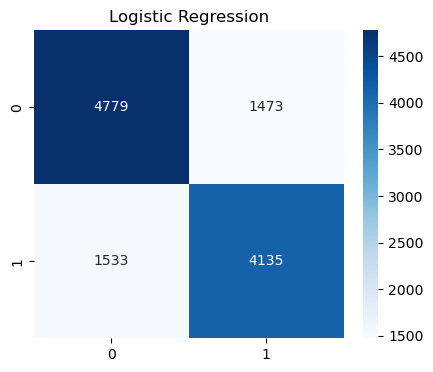

In [69]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_valid, lr_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Logistic Regression")
plt.show()

In [26]:
dt = DecisionTreeClassifier(
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_valid)
results["Decision Tree"] = {
    "Accuracy": accuracy_score(y_valid, dt_pred),
    "Precision": precision_score(y_valid, dt_pred),
    "Recall": recall_score(y_valid, dt_pred),
    "F1": f1_score(y_valid, dt_pred)
}
print(classification_report(y_valid, dt_pred))

              precision    recall  f1-score   support

           0       0.68      0.68      0.68      6252
           1       0.64      0.65      0.65      5668

    accuracy                           0.66     11920
   macro avg       0.66      0.66      0.66     11920
weighted avg       0.66      0.66      0.66     11920



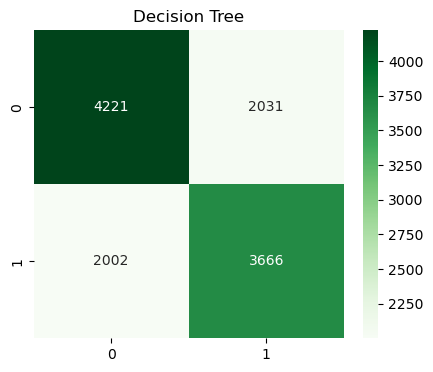

In [27]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_valid, dt_pred),
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title("Decision Tree")
plt.show()

In [28]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_valid)
results["Random Forest"] = {
    "Accuracy": accuracy_score(y_valid, rf_pred),
    "Precision": precision_score(y_valid, rf_pred),
    "Recall": recall_score(y_valid, rf_pred),
    "F1": f1_score(y_valid, rf_pred)
}
print(classification_report(y_valid, rf_pred))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76      6252
           1       0.74      0.72      0.73      5668

    accuracy                           0.75     11920
   macro avg       0.75      0.74      0.75     11920
weighted avg       0.75      0.75      0.75     11920



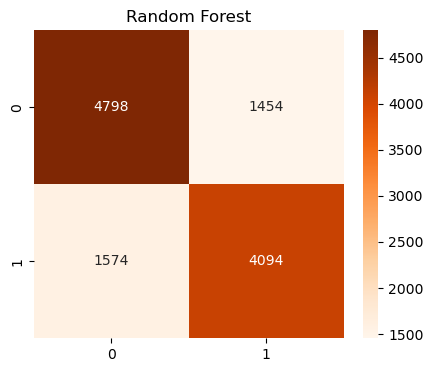

In [29]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_valid, rf_pred),
    annot=True,
    fmt='d',
    cmap='Oranges'
)
plt.title("Random Forest")
plt.show()

In [30]:
knn = KNeighborsClassifier(
    n_neighbors=5
)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_valid_scaled)
results["KNN"] = {
    "Accuracy": accuracy_score(y_valid, knn_pred),
    "Precision": precision_score(y_valid, knn_pred),
    "Recall": recall_score(y_valid, knn_pred),
    "F1": f1_score(y_valid, knn_pred)
}
print(classification_report(y_valid, knn_pred))

              precision    recall  f1-score   support

           0       0.69      0.67      0.68      6252
           1       0.65      0.67      0.66      5668

    accuracy                           0.67     11920
   macro avg       0.67      0.67      0.67     11920
weighted avg       0.67      0.67      0.67     11920



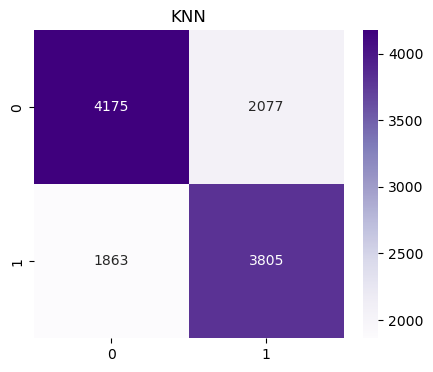

In [31]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_valid, knn_pred),
    annot=True,
    fmt='d',
    cmap='Purples'
)
plt.title("KNN")
plt.show()

In [75]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1
Logistic Regression,0.747819,0.737340,0.729534,0.733416
Decision Tree,0.661661,0.643497,0.646789,0.645139
Random Forest,0.745973,0.737924,0.722301,0.730029
KNN,0.669463,0.646889,0.671313,0.658874
XGBoost,0.750503,0.738070,0.736768,0.737418


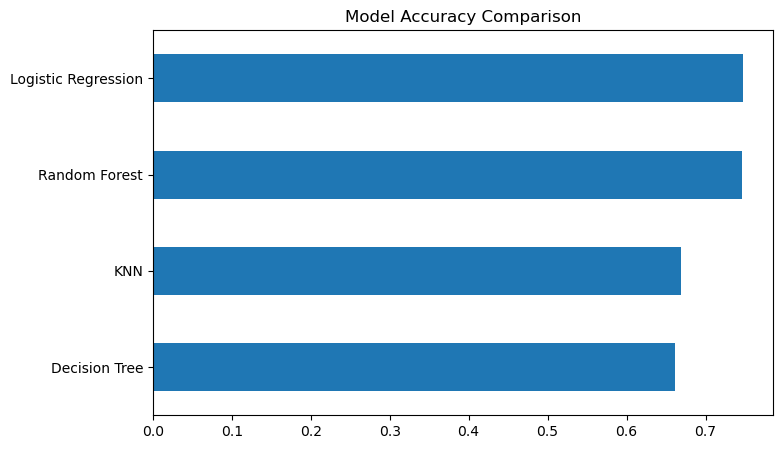

In [33]:
results_df["Accuracy"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)
plt.title("Model Accuracy Comparison")
plt.show()

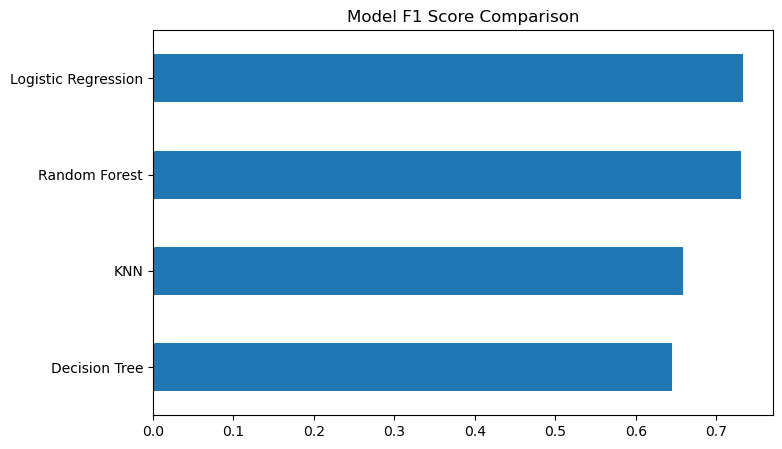

In [34]:
results_df["F1"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)
plt.title("Model F1 Score Comparison")
plt.show()

In [36]:
from xgboost import XGBClassifier

In [37]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_valid)

In [38]:
results["XGBoost"] = {
    "Accuracy": accuracy_score(y_valid, xgb_pred),
    "Precision": precision_score(y_valid, xgb_pred),
    "Recall": recall_score(y_valid, xgb_pred),
    "F1": f1_score(y_valid, xgb_pred)
}
print(classification_report(y_valid, xgb_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76      6252
           1       0.74      0.74      0.74      5668

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



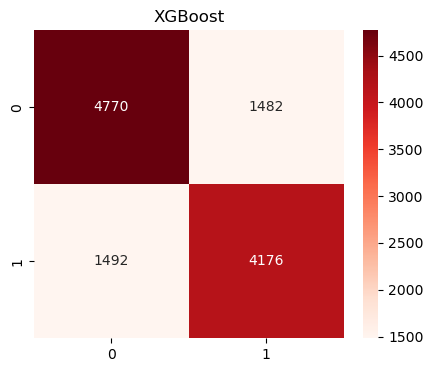

In [39]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_valid, xgb_pred),
    annot=True,
    fmt='d',
    cmap='Reds'
)
plt.title("XGBoost")
plt.show()

In [40]:
results_df = pd.DataFrame(results).T
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Accuracy,Precision,Recall,F1
XGBoost,0.750503,0.738070,0.736768,0.737418
Logistic Regression,0.747819,0.737340,0.729534,0.733416
Random Forest,0.745973,0.737924,0.722301,0.730029
KNN,0.669463,0.646889,0.671313,0.658874
Decision Tree,0.661661,0.643497,0.646789,0.645139


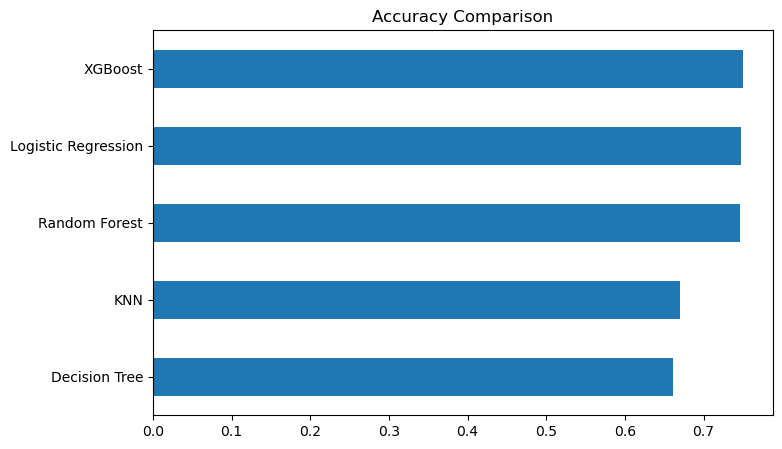

In [77]:
results_df["Accuracy"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)
plt.title("Accuracy Comparison")
plt.show()

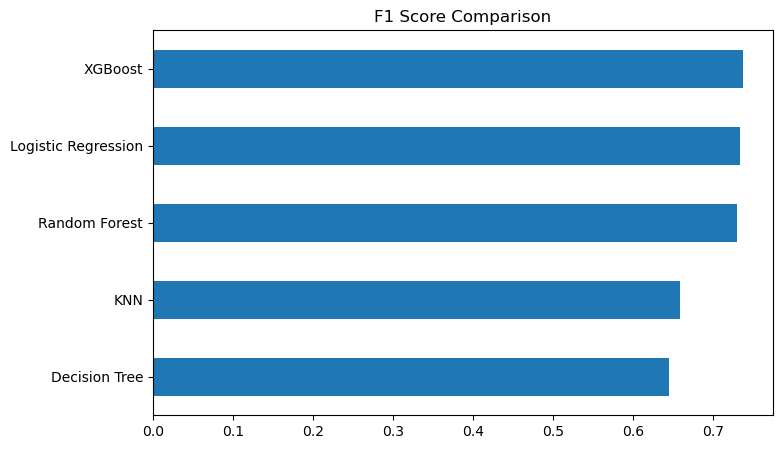

In [42]:
results_df["F1"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)
plt.title("F1 Score Comparison")
plt.show()

In [43]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(15)

,Feature,Importance
27,Marital Status_Single,0.143813
29,Job Level_Senior,0.138394
32,Remote Work_Yes,0.100513
28,Job Level_Mid,0.061940
14,Work-Life Balance_Poor,0.050951
25,Education Level_PhD,0.047293
12,Work-Life Balance_Fair,0.045737
7,Gender_Male,0.034976
3,Number of Promotions,0.027059
37,Company Reputation_Poor,0.026408


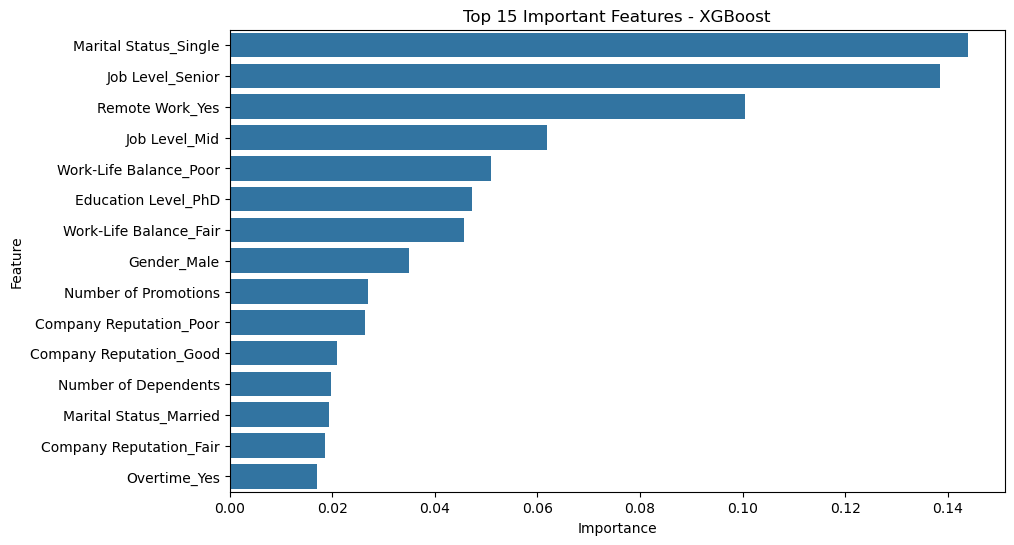

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Important Features - XGBoost")
plt.show()

In [45]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance.head(15)

,Feature,Importance
4,Distance from Home,0.081046
2,Monthly Income,0.077391
6,Company Tenure,0.073615
29,Job Level_Senior,0.069790
0,Age,0.068318
1,Years at Company,0.068178
27,Marital Status_Single,0.053251
32,Remote Work_Yes,0.045973
5,Number of Dependents,0.042878
3,Number of Promotions,0.037243


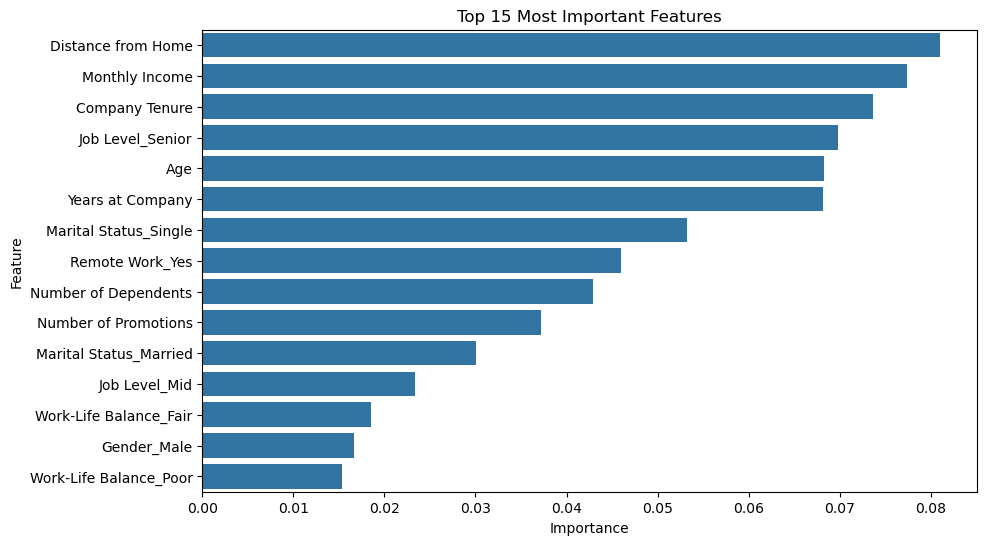

In [46]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Most Important Features")
plt.show()

In [81]:
corr_target = train.corr(numeric_only=True)["Attrition"]\
                   .sort_values(ascending=False)
corr_target

Attrition               1.000000
Distance from Home      0.095570
Monthly Income         -0.011377
Company Tenure         -0.030285
Age                    -0.048900
Years at Company       -0.064909
Number of Dependents   -0.078337
Number of Promotions   -0.080591
Name: Attrition, dtype: float64

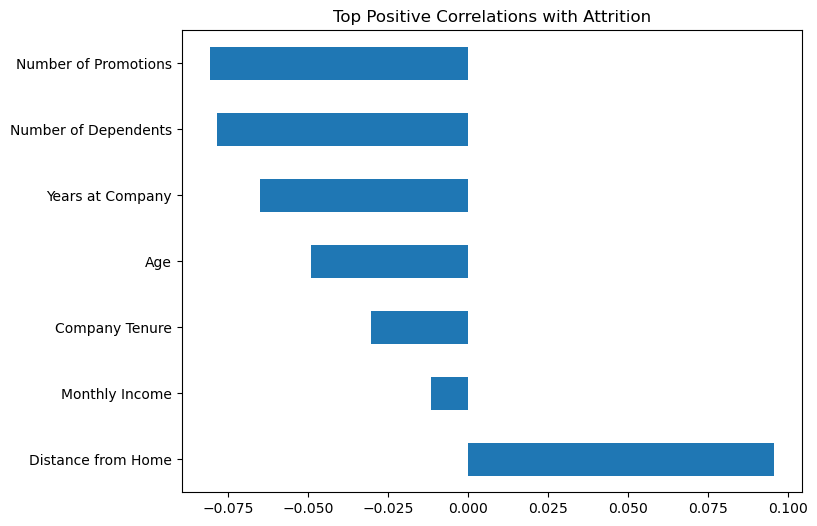

In [48]:
plt.figure(figsize=(8,6))

corr_target.drop("Attrition").head(10).plot(
    kind="barh"
)

plt.title("Top Positive Correlations with Attrition")
plt.show()

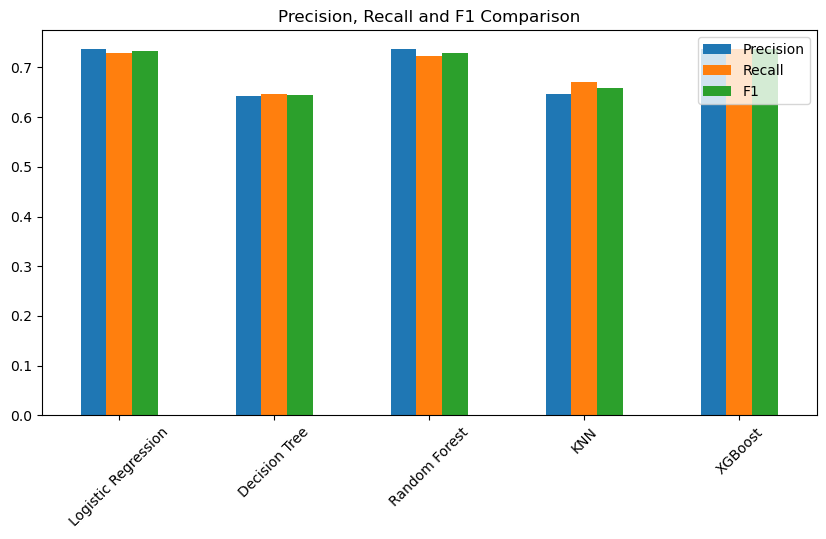

In [87]:
results_df[
    ["Precision","Recall","F1"]
].plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Precision, Recall and F1 Comparison")
plt.xticks(rotation=45)
plt.show()

In [53]:
errors = X_valid.copy()
errors["Actual"] = y_valid.values
errors["Predicted"] = xgb_pred
errors = errors[
    errors["Actual"] != errors["Predicted"]
]
print("Number of Misclassified Samples:",
      len(errors))

Number of Misclassified Samples: 2974


In [54]:
errors.head(10)

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,Gender_Male,Job Role_Finance,Job Role_Healthcare,...,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High,Actual,Predicted
56753,45,26,10787,0,2,3,42,True,True,False,...,False,False,True,False,False,True,False,False,1,0
9170,27,3,5093,0,31,2,36,True,False,False,...,False,True,False,True,False,False,True,False,1,0
982,55,39,6793,0,1,1,72,True,False,True,...,False,False,False,True,False,False,False,False,1,0
41112,49,21,5723,3,41,0,22,True,False,False,...,False,False,True,False,False,False,False,True,1,0
27741,20,7,4709,0,32,3,54,True,False,False,...,False,False,True,False,False,True,False,False,0,1
27252,31,15,4855,0,35,4,92,False,False,False,...,False,False,False,False,True,False,True,False,0,1
58540,37,22,11682,1,22,3,75,True,False,False,...,False,False,False,True,False,False,False,False,0,1
28520,48,32,3581,2,38,0,45,True,False,False,...,False,False,False,True,False,False,True,False,1,0
50956,48,7,5948,0,90,1,9,True,False,False,...,False,False,False,False,True,False,False,False,0,1
42351,42,1,5888,0,14,0,59,True,False,False,...,False,False,False,True,False,False,True,False,1,0


### From-Scratch Implementation


In [55]:
import numpy as np
class KNNFromScratch:
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
    def predict(self, X):
        X = np.array(X)
        predictions = []
        for x in X:
            distances = np.sqrt(
                np.sum((self.X_train - x)**2, axis=1)
            )
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            prediction = np.bincount(k_labels).argmax()
            predictions.append(prediction)
        return np.array(predictions)

In [56]:
knn_scratch = KNNFromScratch(k=5)
knn_scratch.fit(
    X_train_scaled,
    y_train
)
knn_scratch_pred = knn_scratch.predict(
    X_valid_scaled
)
print(
    "Accuracy:",
    accuracy_score(
        y_valid,
        knn_scratch_pred
    )
)

Accuracy: 0.6694630872483222


In [57]:
class LogisticRegressionScratch:
    def __init__(
        self,
        lr=0.01,
        epochs=1000
    ):
        self.lr = lr
        self.epochs = epochs
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.epochs):
            linear = np.dot(
                X,
                self.weights
            ) + self.bias
            y_pred = self.sigmoid(linear)
            dw = (1/n_samples) * np.dot(
                X.T,
                (y_pred - y)
            )
            db = (1/n_samples) * np.sum(
                y_pred - y
            )
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    def predict(self, X):
        linear = np.dot(
            X,
            self.weights
        ) + self.bias
        probs = self.sigmoid(linear)
        return (probs >= 0.5).astype(int)

In [58]:
lr_scratch = LogisticRegressionScratch(
    lr=0.01,
    epochs=1000
)
lr_scratch.fit(
    X_train_scaled,
    y_train
)
lr_scratch_pred = lr_scratch.predict(
    X_valid_scaled
)
print(
    "Accuracy:",
    accuracy_score(
        y_valid,
        lr_scratch_pred
    )
)

Accuracy: 0.7449664429530202


In [59]:
comparison = pd.DataFrame({
    "Model":[
        "KNN Library",
        "KNN Scratch",
        "Logistic Library",
        "Logistic Scratch"
    ],
    "Accuracy":[
        accuracy_score(y_valid, knn_pred),
        accuracy_score(y_valid, knn_scratch_pred),
        accuracy_score(y_valid, lr_pred),
        accuracy_score(y_valid, lr_scratch_pred)
    ]
})
comparison

,Model,Accuracy
0,KNN Library,0.669463
1,KNN Scratch,0.669463
2,Logistic Library,0.747819
3,Logistic Scratch,0.744966


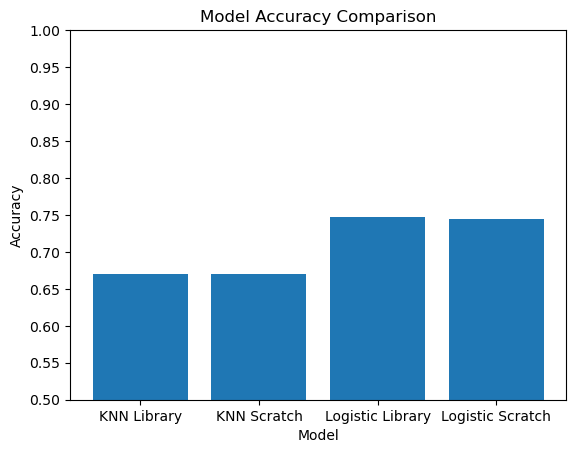

In [120]:
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.ylim(0.5, 1.0) 
plt.yticks(np.arange(0.5, 1.01, 0.05))
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

### Artificial Neural Networks

In [104]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [105]:
ann = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )

])

In [106]:
ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 128)                 │           5,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,745 (61.50 KB)

 Trainable params: 15,745 (61.50 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [108]:
history = ann.fit(
    X_train_scaled,
    y_train,
    validation_data=(
        X_valid_scaled,
        y_valid
    ),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7271 - loss: 0.5286 - val_accuracy: 0.7465 - val_loss: 0.4859
Epoch 2/20
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7482 - loss: 0.4963 - val_accuracy: 0.7471 - val_loss: 0.4843
Epoch 3/20
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7486 - loss: 0.4891 - val_accuracy: 0.7474 - val_loss: 0.4801
Epoch 4/20
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7519 - loss: 0.4841 - val_accuracy: 0.7505 - val_loss: 0.4797
Epoch 5/20
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7536 - loss: 0.4830 - val_accuracy: 0.7482 - val_loss: 0.4777
Epoch 6/20
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7557 - loss: 0.4798 - val_accuracy: 0.7492 - val_loss: 0.4747
Epoch 7/20
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7542 - loss: 0.4785 - val_accuracy: 0.7477 - val_loss: 0.4753
Epoch 8/20
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7543 - loss: 0.4769 - 

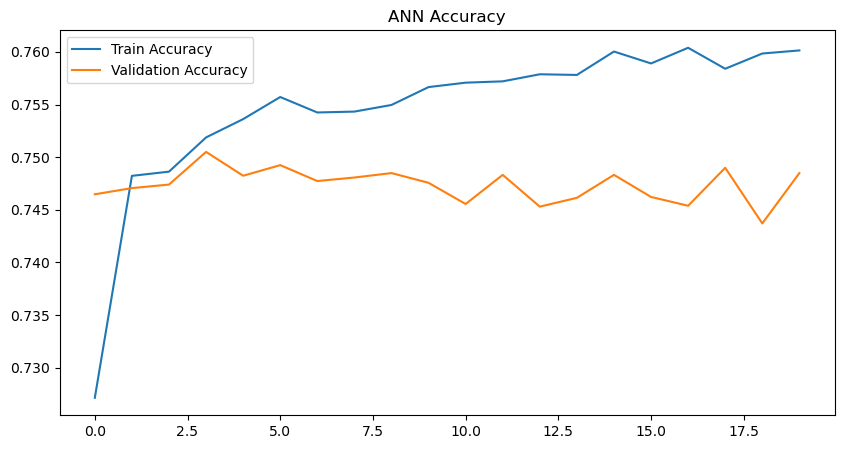

In [109]:
plt.figure(figsize=(10,5))
plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.legend()
plt.title("ANN Accuracy")
plt.show()

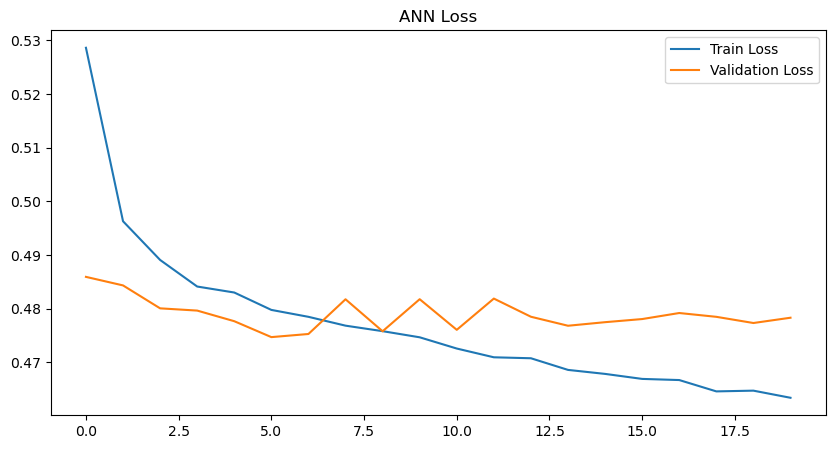

In [110]:
plt.figure(figsize=(10,5))
plt.plot(
    history.history['loss'],
    label='Train Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)
plt.legend()
plt.title("ANN Loss")
plt.show()

In [111]:
ann_probs = ann.predict(
    X_valid_scaled
)
ann_pred = (
    ann_probs > 0.5
).astype(int)

373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step


In [112]:
print(
    classification_report(
        y_valid,
        ann_pred
    )
)

              precision    recall  f1-score   support

           0       0.77      0.74      0.76      6252
           1       0.73      0.76      0.74      5668

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



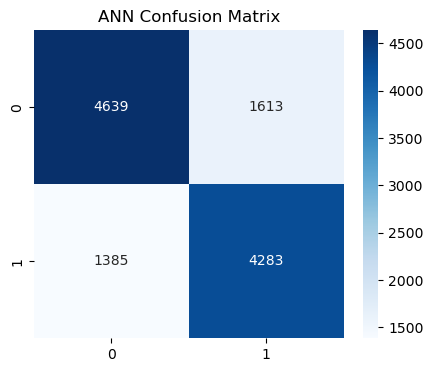

In [113]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(
        y_valid,
        ann_pred
    ),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("ANN Confusion Matrix")
plt.show()

In [114]:
results["ANN"] = {
    "Accuracy":
        accuracy_score(
            y_valid,
            ann_pred
        ),
    "Precision":
        precision_score(
            y_valid,
            ann_pred
        ),
    "Recall":
        recall_score(
            y_valid,
            ann_pred
        ),
    "F1":
        f1_score(
            y_valid,
            ann_pred
        )
}

In [115]:
results_df = pd.DataFrame(results).T
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Accuracy,Precision,Recall,F1
XGBoost,0.750503,0.738070,0.736768,0.737418
ANN,0.748490,0.726425,0.755646,0.740747
Logistic Regression,0.747819,0.737340,0.729534,0.733416
Random Forest,0.745973,0.737924,0.722301,0.730029
KNN,0.669463,0.646889,0.671313,0.658874
Decision Tree,0.661661,0.643497,0.646789,0.645139


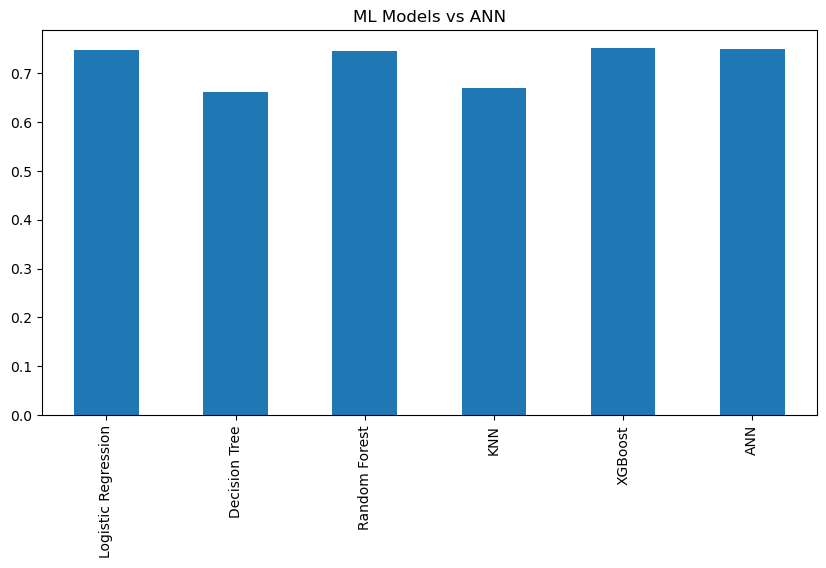

In [116]:
results_df["Accuracy"]\
.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title(
    "ML Models vs ANN"
)
plt.show()

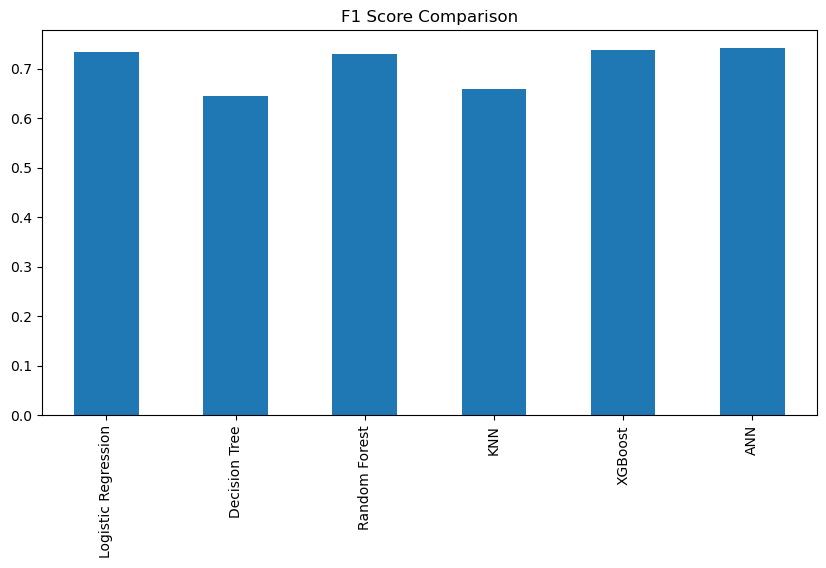

In [117]:
results_df["F1"]\
.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title(
    "F1 Score Comparison"
)
plt.show()

# BY SNEHAL MUDULI